# 03b: Modelling — Approach 2: Loyalty Prediction
First-order features → predict repeat buyer (3.12% positive rate)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
import joblib
import warnings
from sklearn import set_config
set_config(display='text')
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
df = pd.read_csv('../processed/loyalty_modelling_dataset.csv')

target_cols = ['y_loyalty', 'y_future_order_value', 'y_future_order_value_log']
drop_cols = ['customer_unique_id'] + target_cols

X = df.drop(columns=drop_cols)
y_loyalty = df['y_loyalty']
y_value_log = df['y_future_order_value_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_loyalty, test_size=0.2, random_state=42, stratify=y_loyalty
)
y_train_val = y_value_log.loc[y_train.index]
y_test_val = y_value_log.loc[y_test.index]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive rate — Train: {y_train.mean()*100:.2f}%, Test: {y_test.mean()*100:.2f}%")

Train: (76876, 34), Test: (19220, 34)
Positive rate — Train: 3.12%, Test: 3.12%


In [5]:
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_model(name, y_true, y_scores, best_params, cv_score):
    """Evaluate and store all metrics for a model"""
    # Find optimal threshold using F1
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores)]
    y_pred = (y_scores >= best_threshold).astype(int)
    
    result = {
        'best_params': best_params,
        'cv_pr_auc': cv_score,
        'test_roc_auc': roc_auc_score(y_true, y_scores),
        'test_pr_auc': average_precision_score(y_true, y_scores),
        'best_threshold': best_threshold,
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'y_scores': y_scores
    }
    
    print(f"\n{name}:")
    print(f"  Best Params: {best_params}")
    print(f"  CV PR-AUC:    {result['cv_pr_auc']:.4f}")
    print(f"  Test ROC-AUC: {result['test_roc_auc']:.4f}")
    print(f"  Test PR-AUC:  {result['test_pr_auc']:.4f}")
    print(f"  Threshold:    {result['best_threshold']:.4f}")
    print(f"  Precision:    {result['precision']:.4f}")
    print(f"  Recall:       {result['recall']:.4f}")
    print(f"  F1:           {result['f1']:.4f}")
    
    return result

results = {}

In [8]:
# === 1. Logistic Regression ===
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],
    'max_iter': [10000],
    'class_weight': ['balanced', None]
}

lr_search = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid, scoring='average_precision',
    cv=3, n_jobs=-1, verbose=1
)
lr_search.fit(X_train_scaled, y_train)
y_scores_lr = lr_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]
results['Logistic Regression'] = evaluate_model(
    'Logistic Regression', y_test, y_scores_lr, lr_search.best_params_, lr_search.best_score_
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Logistic Regression:
  Best Params: {'C': 1, 'class_weight': None, 'max_iter': 10000, 'penalty': 'l1', 'solver': 'saga'}
  CV PR-AUC:    0.0608
  Test ROC-AUC: 0.6097
  Test PR-AUC:  0.0520
  Threshold:    0.0438
  Precision:    0.0577
  Recall:       0.2437
  F1:           0.0933


In [9]:
# === 2. Random Forest ===
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, n_iter=40, scoring='average_precision',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
y_scores_rf = rf_search.best_estimator_.predict_proba(X_test)[:, 1]
results['Random Forest'] = evaluate_model(
    'Random Forest', y_test, y_scores_rf, rf_search.best_params_, rf_search.best_score_
)

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Random Forest:
  Best Params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 7, 'class_weight': None}
  CV PR-AUC:    0.0685
  Test ROC-AUC: 0.6268
  Test PR-AUC:  0.0604
  Threshold:    0.0431
  Precision:    0.0609
  Recall:       0.2137
  F1:           0.0947


In [10]:
# === 3. Balanced Random Forest ===
brf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 0.7],
    'sampling_strategy': ['all', 'majority'],
}

brf_search = RandomizedSearchCV(
    BalancedRandomForestClassifier(random_state=42, n_jobs=-1),
    brf_param_grid, n_iter=40, scoring='average_precision',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)
brf_search.fit(X_train, y_train)
y_scores_brf = brf_search.best_estimator_.predict_proba(X_test)[:, 1]
results['Balanced Random Forest'] = evaluate_model(
    'Balanced Random Forest', y_test, y_scores_brf, brf_search.best_params_, brf_search.best_score_
)

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Balanced Random Forest:
  Best Params: {'sampling_strategy': 'majority', 'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 7}
  CV PR-AUC:    0.0673
  Test ROC-AUC: 0.6274
  Test PR-AUC:  0.0567
  Threshold:    0.5009
  Precision:    0.0537
  Recall:       0.4825
  F1:           0.0967


In [11]:
# === 4. XGBoost ===
scale_ratio = int(len(y_train[y_train == 0]) / len(y_train[y_train == 1]))

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'scale_pos_weight': [1, 10, scale_ratio],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='aucpr', n_jobs=-1),
    xgb_param_grid, n_iter=50, scoring='average_precision',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
y_scores_xgb = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]
results['XGBoost'] = evaluate_model(
    'XGBoost', y_test, y_scores_xgb, xgb_search.best_params_, xgb_search.best_score_
)

Fitting 3 folds for each of 50 candidates, totalling 150 fits

XGBoost:
  Best Params: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
  CV PR-AUC:    0.0866
  Test ROC-AUC: 0.6407
  Test PR-AUC:  0.0902
  Threshold:    0.0637
  Precision:    0.0897
  Recall:       0.1536
  F1:           0.1132


In [12]:
# === 5. LightGBM ===
lgbm_param_grid = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6, -1],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 50, 70],
    'min_child_samples': [5, 10, 20, 50],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'is_unbalance': [True, False],
    'scale_pos_weight': [1, 10, scale_ratio],
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1),
    lgbm_param_grid, n_iter=50, scoring='average_precision',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)
lgbm_search.fit(X_train, y_train)
y_scores_lgbm = lgbm_search.best_estimator_.predict_proba(X_test)[:, 1]
results['LightGBM'] = evaluate_model(
    'LightGBM', y_test, y_scores_lgbm, lgbm_search.best_params_, lgbm_search.best_score_
)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot set is_unbalance and scale_pos_weight at the same time
[LightGBM] [Fatal] Cannot se


LightGBM:
  Best Params: {'subsample': 0.9, 'scale_pos_weight': 1, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.03, 'is_unbalance': False, 'colsample_bytree': 1.0}
  CV PR-AUC:    0.0914
  Test ROC-AUC: 0.6412
  Test PR-AUC:  0.0912
  Threshold:    0.0616
  Precision:    0.0920
  Recall:       0.1386
  F1:           0.1106


In [13]:
print("\n" + "="*60)
print("CLASSIFICATION MODEL COMPARISON")
print("="*60)
for name, res in results.items():
    print(f"\n{name}:")
    print(f"  Best Params: {res['best_params']}")
    print(f"  CV PR-AUC:   {res['cv_pr_auc']}")
    print(f"  Test ROC-AUC: {res['test_roc_auc']:.4f}")
    print(f"  Test PR-AUC:  {res['test_pr_auc']:.4f}")


CLASSIFICATION MODEL COMPARISON

Logistic Regression:
  Best Params: {'C': 1, 'class_weight': None, 'max_iter': 10000, 'penalty': 'l1', 'solver': 'saga'}
  CV PR-AUC:   0.06077046223193805
  Test ROC-AUC: 0.6097
  Test PR-AUC:  0.0520

Random Forest:
  Best Params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 7, 'class_weight': None}
  CV PR-AUC:   0.06849285934108189
  Test ROC-AUC: 0.6268
  Test PR-AUC:  0.0604

Balanced Random Forest:
  Best Params: {'sampling_strategy': 'majority', 'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 7}
  CV PR-AUC:   0.06733510986347706
  Test ROC-AUC: 0.6274
  Test PR-AUC:  0.0567

XGBoost:
  Best Params: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
  CV PR-AUC:   0.08660558588404645
  Test ROC-AUC: 0.6407
  Test PR-AUC:  0.0902

LightGBM:
  Best Params: {'subsample': 0.9, 'scale_pos_weight': 1, 'num_le

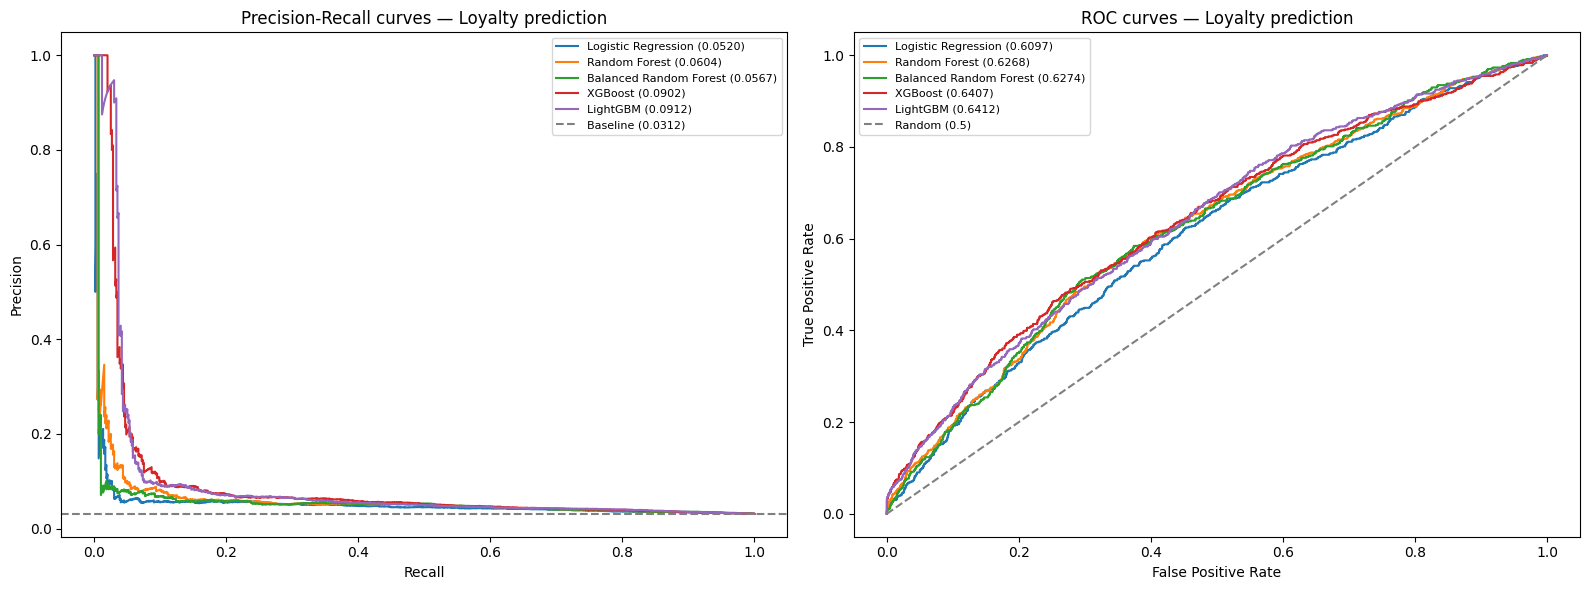

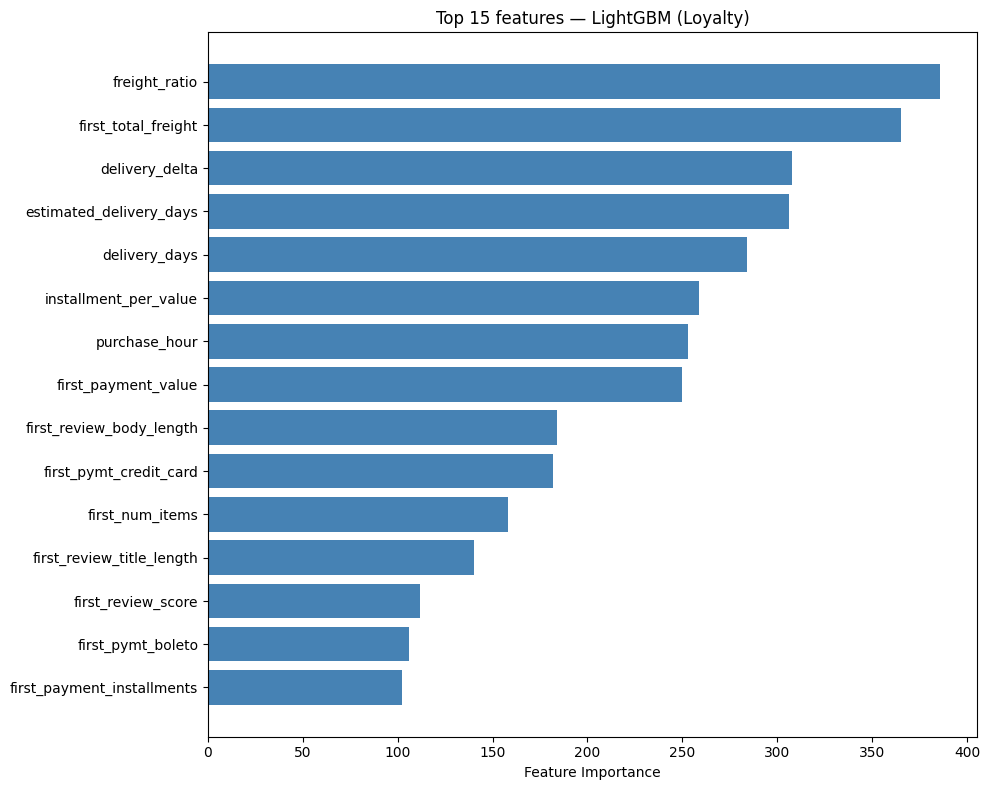

In [14]:
# PR and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_scores'])
    axes[0].plot(recall, precision, label=f"{name} ({res['test_pr_auc']:.4f})")

axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', label=f"Baseline ({y_test.mean():.4f})")
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall curves — Loyalty prediction')
axes[0].legend(fontsize=8)

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_scores'])
    axes[1].plot(fpr, tpr, label=f"{name} ({res['test_roc_auc']:.4f})")

axes[1].plot([0,1], [0,1], color='gray', linestyle='--', label='Random (0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curves — Loyalty prediction')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/loyalty_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance from best model (LightGBM)
best_model = lgbm_search.best_estimator_
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 features — LightGBM (Loyalty)')
plt.tight_layout()
plt.savefig('../outputs/loyalty_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Save best model
joblib.dump(best_model, '../outputs/best_loyalty_model.pkl')
print("Saved best loyalty model (LightGBM)")

Saved best loyalty model (LightGBM)


In [16]:
# === REGRESSION: Future Order Value ===
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

buyer_mask_train = y_train == 1
buyer_mask_test = y_test == 1

X_train_reg = X_train[buyer_mask_train]
X_test_reg = X_test[buyer_mask_test]
y_train_reg = y_train_val[buyer_mask_train]
y_test_reg = y_test_val[buyer_mask_test]

print(f"Regression train: {X_train_reg.shape[0]}, test: {X_test_reg.shape[0]}")

reg_results = {}

Regression train: 2398, test: 599


In [17]:
# Ridge
ridge_search = GridSearchCV(
    Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]},
    scoring='neg_mean_absolute_error', cv=3, n_jobs=-1
)
ridge_search.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge_search.best_estimator_.predict(X_test_reg)
reg_results['Ridge'] = {
    'best_params': ridge_search.best_params_,
    'mae': mean_absolute_error(np.expm1(y_test_reg), np.expm1(y_pred_ridge)),
    'rmse': np.sqrt(mean_squared_error(np.expm1(y_test_reg), np.expm1(y_pred_ridge)))
}

# Random Forest
rf_reg_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [100, 200, 300, 500], 'max_depth': [3, 5, 7, None],
     'min_samples_leaf': [1, 3, 5, 10], 'max_features': ['sqrt', 0.5, 0.7, 1.0]},
    n_iter=30, scoring='neg_mean_absolute_error', cv=3, random_state=42, n_jobs=-1
)
rf_reg_search.fit(X_train_reg, y_train_reg)
y_pred_rf = rf_reg_search.best_estimator_.predict(X_test_reg)
reg_results['Random Forest'] = {
    'best_params': rf_reg_search.best_params_,
    'mae': mean_absolute_error(np.expm1(y_test_reg), np.expm1(y_pred_rf)),
    'rmse': np.sqrt(mean_squared_error(np.expm1(y_test_reg), np.expm1(y_pred_rf)))
}

In [18]:
# XGBoost
xgb_reg_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    {'n_estimators': [100, 200, 300, 500], 'max_depth': [3, 4, 5, 6],
     'learning_rate': [0.01, 0.03, 0.05, 0.1], 'subsample': [0.6, 0.7, 0.8, 0.9],
     'colsample_bytree': [0.6, 0.7, 0.8, 1.0], 'min_child_weight': [1, 3, 5]},
    n_iter=30, scoring='neg_mean_absolute_error', cv=3, random_state=42, n_jobs=-1
)
xgb_reg_search.fit(X_train_reg, y_train_reg)
y_pred_xgb = xgb_reg_search.best_estimator_.predict(X_test_reg)
reg_results['XGBoost'] = {
    'best_params': xgb_reg_search.best_params_,
    'mae': mean_absolute_error(np.expm1(y_test_reg), np.expm1(y_pred_xgb)),
    'rmse': np.sqrt(mean_squared_error(np.expm1(y_test_reg), np.expm1(y_pred_xgb)))
}

print("\n" + "="*50)
print("REGRESSION MODEL COMPARISON — Future Order Value")
print("="*50)
for name, res in reg_results.items():
    print(f"\n{name}:")
    print(f"  Best Params: {res['best_params']}")
    print(f"  MAE:  ${res['mae']:.2f}")
    print(f"  RMSE: ${res['rmse']:.2f}")


REGRESSION MODEL COMPARISON — Future Order Value

Ridge:
  Best Params: {'alpha': 0.01}
  MAE:  $72.38
  RMSE: $141.82

Random Forest:
  Best Params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 5}
  MAE:  $67.13
  RMSE: $136.89

XGBoost:
  Best Params: {'subsample': 0.6, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  MAE:  $68.06
  RMSE: $139.65


In [19]:
# Save best regression model
best_reg_name = min(reg_results, key=lambda x: reg_results[x]['mae'])
if best_reg_name == 'Random Forest':
    joblib.dump(rf_reg_search.best_estimator_, '../outputs/best_loyalty_value_model.pkl')
elif best_reg_name == 'XGBoost':
    joblib.dump(xgb_reg_search.best_estimator_, '../outputs/best_loyalty_value_model.pkl')
else:
    joblib.dump(ridge_search.best_estimator_, '../outputs/best_loyalty_value_model.pkl')
print(f"\nSaved best regression model ({best_reg_name})")


Saved best regression model (Random Forest)


In [20]:
# Final comparison table
print("\n" + "="*70)
print("FINAL RESULTS — Approach 2: Loyalty Prediction")
print("="*70)

print("\n--- Classification: Repeat Buyer Prediction ---")
print(f"{'Model':<25} {'ROC-AUC':>10} {'PR-AUC':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print("-"*75)
for name, res in results.items():
    print(f"{name:<25} {res['test_roc_auc']:>10.4f} {res['test_pr_auc']:>10.4f} {res['f1']:>10.4f} {res['precision']:>10.4f} {res['recall']:>10.4f}")

print(f"\n--- Regression: Future Order Value ---")
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10}")
print("-"*45)
for name, res in reg_results.items():
    print(f"{name:<25} ${res['mae']:>8.2f} ${res['rmse']:>8.2f}")

print("\n--- Best Models ---")
print(f"Classification: LightGBM (PR-AUC: {results['LightGBM']['test_pr_auc']:.4f})")
print(f"Regression: Random Forest (MAE: ${reg_results['Random Forest']['mae']:.2f})")


FINAL RESULTS — Approach 2: Loyalty Prediction

--- Classification: Repeat Buyer Prediction ---
Model                        ROC-AUC     PR-AUC         F1  Precision     Recall
---------------------------------------------------------------------------
Logistic Regression           0.6097     0.0520     0.0933     0.0577     0.2437
Random Forest                 0.6268     0.0604     0.0947     0.0609     0.2137
Balanced Random Forest        0.6274     0.0567     0.0967     0.0537     0.4825
XGBoost                       0.6407     0.0902     0.1132     0.0897     0.1536
LightGBM                      0.6412     0.0912     0.1106     0.0920     0.1386

--- Regression: Future Order Value ---
Model                            MAE       RMSE
---------------------------------------------
Ridge                     $   72.38 $  141.82
Random Forest             $   67.13 $  136.89
XGBoost                   $   68.06 $  139.65

--- Best Models ---
Classification: LightGBM (PR-AUC: 0.0912)
Regres

---

## Approach 2: Loyalty Prediction (First-Order Features)

The temporal approach (Approach 1) yielded limited signal due to only 293 positive examples (0.35%). As a complementary analysis, the problem was reframed: **given a customer's first order, will they ever return?**

### Key Differences from Approach 1

| Aspect | Approach 1 (Temporal) | Approach 2 (Loyalty) |
|---|---|---|
| Target | Ordered in next 90 days? | Ever ordered more than once? |
| Positive rate | 0.35% (293 users) | 3.12% (2,997 users) |
| Features | Aggregated history (all orders) | First order only |
| Use case | Short-term ad targeting | Lifetime value identification |

### Feature Engineering

34 features extracted from each customer's first order only:
- **Payment behavior:** value, installments, payment type split, installment-to-value ratio
- **Order composition:** item count, seller count, total price, freight, freight ratio
- **Review engagement:** score, title length, body length
- **Delivery experience:** delivery days, estimated days, delivery delta (early vs late)
- **Purchase context:** hour of day, day of week, delivery status

### Classification Results

| Model | ROC-AUC | PR-AUC | F1 | Precision | Recall |
|---|---|---|---|---|---|
| Logistic Regression | 0.6097 | 0.0520 | 0.0933 | 0.0577 | 0.2437 |
| Random Forest | 0.6268 | 0.0604 | 0.0947 | 0.0609 | 0.2137 |
| Balanced Random Forest | 0.6274 | 0.0567 | 0.0967 | 0.0537 | 0.4825 |
| XGBoost | 0.6407 | 0.0902 | 0.1132 | 0.0897 | 0.1536 |
| **LightGBM** | **0.6412** | **0.0912** | **0.1106** | **0.0920** | **0.1386** |

![Loyalty PR and ROC Curves](outputs/loyalty_pr_roc_curves.png)

### Top Features (LightGBM)

![Loyalty Feature Importance](outputs/loyalty_feature_importance.png)

- **Freight ratio** (freight as % of order value) is the #1 predictor — customers buying heavy/distant items show different loyalty patterns
- **Delivery experience** features (delivery_delta, estimated_delivery_days, delivery_days) are top 5 — late deliveries reduce repeat likelihood
- **Ratio features** (installment_per_value, freight_ratio) outperform raw values, confirming that behavioral intensity matters more than scale

### Regression Results (Future Order Value)

| Model | MAE | RMSE |
|---|---|---|
| Ridge | $72.38 | $141.82 |
| **Random Forest** | **$67.13** | **$136.89** |
| XGBoost | $68.06 | $139.65 |

### Approach Comparison

| Metric | Approach 1 (Temporal) | Approach 2 (Loyalty) |
|---|---|---|
| Best PR-AUC | 0.0077 | **0.0912** (12x improvement) |
| Best ROC-AUC | 0.6171 | **0.6412** |
| Regression MAE | $55.75 | $67.13 |
| Positive examples | 293 | 2,997 |

Approach 2 dramatically outperforms Approach 1 on classification due to 10x more positive examples. Approach 1 has lower regression MAE because it predicts on a narrower, more recent time window.